# A Short Introduction to the Quantum Approximate Optimization Algorithm

## From adiabatic quantum computation to optimization

A useful way to motivate the Quantum Approximate Optimization Algorithm (QAOA) is to start from **adiabatic quantum computation**. The basic idea is to encode the solution of a computational problem into the ground state of a problem Hamiltonian $H_P$, and then to prepare that ground state by slowly transforming an initial Hamiltonian $H_B$, whose ground state is easy to prepare, into $H_P$.

A standard interpolation is

$$
H(s) = (1-s)H_B + sH_P,
\qquad 0\le s\le 1.
$$

The system is initialized in the ground state of $H_B$,

$$
|\psi(0)\rangle = |\psi_B\rangle.
$$

If the interpolation is sufficiently slow, the adiabatic theorem implies that the evolving state remains close to the instantaneous ground state of $H(s)$. At the end of the evolution,

$$
H(1)=H_P,
$$

and therefore the final state is close to the ground state of the problem Hamiltonian.

The total evolution time required for adiabaticity is controlled by the minimum spectral gap between the ground state and first excited state along the interpolation path. Schematically,

$$
T \gg
\frac{
\max_s
\left|
\langle 1(s)|
\partial_s H(s)
|0(s)\rangle
\right|
}{
\Delta_{\min}^2
},
$$

where

$$
\Delta_{\min}
=
\min_s
\left[
E_1(s)-E_0(s)
\right].
$$

Thus, a small minimum gap can require a long coherent evolution time.

## Encoding an optimization problem into a ground state

Many combinatorial optimization problems can be expressed using binary variables

$$
x_i\in\{0,1\}.
$$

A broad class can be written as a Quadratic Unconstrained Binary Optimization (QUBO) problem,

$$
C(\mathbf{x})
=
c
+
\sum_i a_i x_i
+
\sum_{i<j} b_{ij}x_ix_j,
$$

where the goal is to minimize $C(\mathbf{x})$.

To encode the problem on qubits, one uses

$$
x_i=\frac{1-Z_i}{2},
$$

where $Z_i$ is the Pauli-$Z$ operator acting on qubit $i$. Substituting this mapping into the QUBO objective produces an Ising-type Hamiltonian,

$$
H_P
=
\sum_i h_i Z_i
+
\sum_{i<j}J_{ij}Z_iZ_j
+
\text{const}.
$$

Each computational-basis state

$$
|x_1x_2\cdots x_n\rangle
$$

is an eigenstate of $H_P$, and its eigenvalue is proportional to the corresponding classical cost. Consequently, minimizing the classical objective becomes equivalent to finding the ground state of $H_P$.

The central correspondence is therefore

$$
\boxed{
\text{combinatorial optimization}
\longrightarrow
\text{QUBO}
\longrightarrow
\text{Ising Hamiltonian}
\longrightarrow
\text{ground-state problem}.
}
$$

Constraints can also be incorporated through penalty terms. For example,

$$
\sum_i x_i=B
$$

may be enforced by adding

$$
A\left(\sum_i x_i-B\right)^2,
\qquad A>0,
$$

to the objective.


## Combinatorial optimization as a quantum ground-state problem

The aim of MaxCut is to maximize the number of edges (yellow lines) in a graph that are “cut” by a given partition of the vertices (blue circles) into two sets (see figure below).

<div style="text-align: center;">
  <img src="qaoa_maxcut_partition.png" width="400">
  <br>
  <em>MaxCut on a simple graph</em>
</div>


Consider a graph with $m$ edges and &n& vertices. We seek the partition $x$ of the vertices into two sets $A$ and $B$ that maximises
$$
C(x) = \sum_{\alpha=1}^{m}C_\alpha(x),
$$

where $C$ counts the number of edges cut. $C_{\alpha}(x)=1$ if $x$ places one vertex from the $\alpha^{\mathrm{th}}$ edge in set $A$ and the other in set $B$, and $C_{\alpha}(x)=0$ otherwise.

Finding a cut which yields the maximum possible value of $C$ is an NP-complete problem, so our best hope for a polynomial-time algorithm lies in an approximate optimisation. In the case of MaxCut, this means finding a partition $x$ which yields a value for $C(x)$ that is close to the maximum possible value.

We can represent the assignment of vertices to set $A$ or $B$ using a bitstring,

$$
x = x_1 \cdots x_n,
$$

where $x_i=0$ if the $i^{\mathrm{th}}$ vertex is in $A$ and $z_i=1$ if it is in $B$.

For instance, in the situation depicted in the figure above, the bitstring representation is

$$
x = 0101,
$$

indicating that the $0^{\mathrm{th}}$ and $2^{\mathrm{nd}}$ vertices are in $A$, while the $1^{\mathrm{st}}$ and $3^{\mathrm{rd}}$ are in $B$.

This assignment yields a value for the objective function (the number of yellow lines cut)

$$
C = 4,
$$

which turns out to be the maximum cut.


Let's formalize it.

$$
x_i=
\begin{cases}
0,&i\in A,\\
1,&i\in B.
\end{cases}
$$

For an edge $(i,j)$, the contribution to the cut is

$$
C_{ij}
=
x_i+x_j-2x_ix_j.
$$

Using the binary-to-spin mapping,

$$
x_i=\frac{1-Z_i}{2},
$$

one obtains

$$
\hat C_{ij}
=
\frac12
\left(
I-Z_iZ_j
\right).
$$

The total MaxCut operator is

$$
H_C
=
\sum_{(i,j)\in E}
\frac12
\left(
I-Z_iZ_j
\right).
$$

Its largest eigenvalue corresponds to the maximum cut. Equivalently, one may minimize $-H_C\$.

The same logic applies to many other combinatorial problems, including graph coloring, independent set, traveling-salesman formulations, scheduling problems, and binary portfolio optimization. The essential step is always to map the classical objective and constraints into a diagonal Hamiltonian whose low-energy states encode good solutions.

The example is taken from Pennylane tutorial (https://pennylane.ai/demos/tutorial_qaoa_maxcut)


## From adiabatic evolution to QAOA

Direct adiabatic optimisation may require a long coherent runtime. QAOA replaces the continuous evolution with a finite sequence of alternating unitaries.

Choose a cost Hamiltonian $H_C$, which encodes the objective, and a mixer Hamiltonian (initial Hamiltonian $H_B$)

$$
H_M=\sum_{i=1}^{n}X_i.
$$

The ground state of $-H_M$ is the uniform superposition (initial Hamiltonian $H_B$ with easily preparable graound state)

$$
|+\rangle^{\otimes n}
=
\frac{1}{\sqrt{2^n}}
\sum_{\mathbf{x}}
|\mathbf{x}\rangle.
$$

For one QAOA layer,

$$
|\gamma,\beta\rangle
=
e^{-i\beta H_M}
e^{-i\gamma H_C}
|+\rangle^{\otimes n}.
$$

For $p$ layers,

$$
|\boldsymbol{\gamma},\boldsymbol{\beta}\rangle
=
\prod_{\ell=1}^{p}
e^{-i\beta_\ell H_M}
e^{-i\gamma_\ell H_C}
|+\rangle^{\otimes n},
$$

with

$$
\boldsymbol{\gamma}
=
(\gamma_1,\ldots,\gamma_p),
\qquad
\boldsymbol{\beta}
=
(\beta_1,\ldots,\beta_p).
$$

The parameters are selected by a classical optimiser to optimise

$$
F_p(\boldsymbol{\gamma},\boldsymbol{\beta})
=
\langle
\boldsymbol{\gamma},\boldsymbol{\beta}
|
H_C
|
\boldsymbol{\gamma},\boldsymbol{\beta}
\rangle.
$$

For a maximisation problem such as MaxCut, one maximises $F_p$; for a minimisation problem, one either minimises the corresponding expectation value or reverses the sign convention for the cost Hamiltonian.

## QAOA as a digitized and variational approximation

The connection to adiabatic quantum computation becomes transparent by considering

$$
H(t)=A(t)H_M+B(t)H_C.
$$

For a short interval $\Delta t$,

$$
e^{-i\Delta t[A H_M+B H_C]}
\approx
e^{-i\Delta t A H_M}
e^{-i\Delta t B H_C},
$$

which is a first-order Trotter approximation.

Repeated over many time slices, the evolution takes the form

$$
U
\approx
\prod_{\ell}
e^{-i\beta_\ell H_M}
e^{-i\gamma_\ell H_C},
$$

which has the same alternating structure as QAOA.

Thus QAOA can be viewed as a **digitized, finite-depth, variational analogue of adiabatic optimization**. The important difference is that QAOA does not force the angles

$$
\{\gamma_\ell,\beta_\ell\}
$$

to follow a predetermined, discretised adiabatic schedule. Instead, they are optimised variationally.

As $p$ increases, the ansatz becomes more expressive. In the formal large-$p$ limit, suitably chosen parameters can approximate a digitised adiabatic evolution. On NISQ hardware, however, $p$ is typically kept modest because increasing it also increases circuit depth, two-qubit gate count, optimisation difficulty, and noise sensitivity.

The practical QAOA workflow is therefore

$$
\boxed{
\text{classical optimization problem}
\rightarrow
H_C
\rightarrow
\text{QAOA circuit}
\rightarrow
\langle H_C\rangle
\rightarrow
\text{classical optimization of }
(\boldsymbol{\gamma},\boldsymbol{\beta})
\rightarrow
\text{bit-string sampling}.
}
$$

The measured bit strings are interpreted as candidate solutions of the original combinatorial problem. On a NISQ device, solution quality depends not only on $p$, but also on the classical optimizer, finite-shot statistics, hardware noise, and the way constraints are encoded.

# QAOA for MaxCut — Qiskit version

This notebook is a **Qiskit version of the PennyLane demo**
**“QAOA for MaxCut”** by Angus Lowe and Jay Soni.

In [8]:
import itertools
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit import QuantumCircuit, transpile
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp

np.random.seed(42)

n_qubits = 4
graph = [(0, 1), (0, 3), (1, 2), (2, 3)]

print("Number of vertices:", n_qubits)
print("Edges:", graph)

Number of vertices: 4
Edges: [(0, 1), (0, 3), (1, 2), (2, 3)]


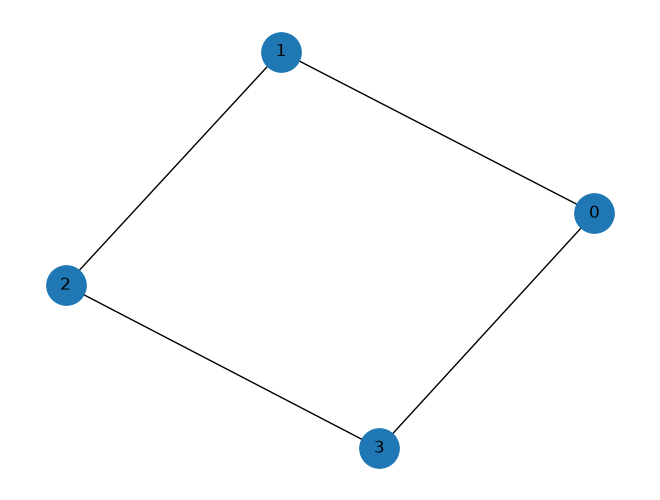

In [9]:
import networkx as nx

G=nx.Graph(); 
G.add_nodes_from(range(n_qubits)); 
G.add_edges_from(graph)
nx.draw(G,nx.spring_layout(G,seed=4),with_labels=True,node_size=800); 
plt.show()

## Classical reference solution

Because this toy example has only four vertices, we can enumerate all (2^4=16) bit strings and verify the exact optimum.


In [10]:
def cut_value(bitstring, edges=graph):
    # bitstring is written in vertex order z0 z1 z2 z3
    return sum(bitstring[j] != bitstring[k] for j, k in edges)

classical_solutions = []

for bits in itertools.product([0, 1], repeat=n_qubits):
    value = cut_value(bits)
    classical_solutions.append((bits, value))

max_cut = max(value for _, value in classical_solutions)
optimal_strings = [
    "".join(map(str, bits))
    for bits, value in classical_solutions
    if value == max_cut
]

print("Exact MaxCut value =", max_cut)
print("Optimal partitions =", optimal_strings)

Exact MaxCut value = 4
Optimal partitions = ['0101', '1010']


## QAOA for MaxCut

For an edge $(j,k)$, the cut operator is

$$
C_{jk}
=
\frac12\left(I-Z_jZ_k\right).
$$

It has eigenvalue $1$ when the two bits differ and $0$ when they agree.

The full objective operator is

$$
C=
\sum_{(j,k)\in E}
\frac12\left(I-Z_jZ_k\right).
$$

QAOA starts from

$$
|+\rangle^{\otimes n}
=
\frac{1}{\sqrt{2^n}}
\sum_z |z\rangle.
$$

For $p$ layers,

$$
|\boldsymbol\gamma,\boldsymbol\beta\rangle
=
U_B(\beta_p)U_C(\gamma_p)
\cdots
U_B(\beta_1)U_C(\gamma_1)
|+\rangle^{\otimes n},
$$

where

$$
U_B(\beta)
=
\prod_{j=0}^{n-1}
e^{-i\beta X_j}
$$

and

$$
U_C(\gamma)
=
\prod_{(j,k)\in E}
e^{-i\gamma C_{jk}}.
$$

Up to a global phase, each edge interaction as can be implemented as

$$
\mathrm{CNOT}_{jk}
\;R_Z(\gamma)_k\;
\mathrm{CNOT}_{jk}.
$$

## Explicit Qiskit implementation

### 3.1 Mixer $U_B$

In [11]:
def U_B(qc, beta):
    # exp(-i beta X) = RX(2 beta)
    for qubit in range(n_qubits):
        qc.rx(2 * beta, qubit)

### Cost unitary $U_C$

In [12]:
def U_C(qc, gamma):
    for j, k in graph:
        qc.cx(j, k)
        qc.rz(gamma, k)
        qc.cx(j, k)

### Build the QAOA circuit

The number of QAOA layers is

$$
p=\text{len}(\boldsymbol\gamma)=\text{len}(\boldsymbol\beta).
$$

In [13]:
def qaoa_circuit(gammas, betas, measure=False):
    if len(gammas) != len(betas):
        raise ValueError("gammas and betas must have the same length")

    qc = QuantumCircuit(n_qubits)

    # |+>^n initial state
    qc.h(range(n_qubits))

    # p QAOA layers
    for gamma, beta in zip(gammas, betas):
        U_C(qc, gamma)
        U_B(qc, beta)

    if measure:
        qc.measure_all()

    return qc

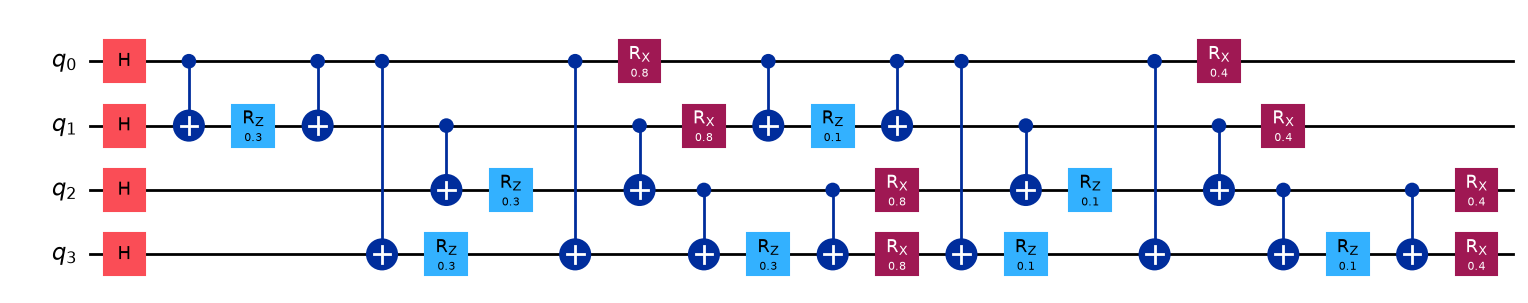

In [33]:
example = qaoa_circuit([0.3, 0.1], [0.4, 0.2])
display(example.draw("mpl", fold=-1))

## Cost expectation value

To evaluate the cost we need to measure

$$
\sum_{(j,k)\in E}\langle Z_jZ_k\rangle
$$

and reconstructs

$$
\langle C\rangle
=
\frac12
\left(
|E|
-
\sum_{(j,k)\in E}
\langle Z_jZ_k\rangle
\right).
$$

We will use Qiskit's `StatevectorEstimator`.

`StatevectorEstimator` is exact for this unitary circuit, which makes the classical optimisation deterministic and easy to reproduce.

Later, we separately sample the optimised circuit with a finite number of shots.

In [15]:
zz_sum = SparsePauliOp.from_sparse_list(
    [("ZZ", [j, k], 1.0) for j, k in graph],
    num_qubits=n_qubits,
)

estimator = StatevectorEstimator()

def expected_cut(params):
    params = np.asarray(params, dtype=float)
    p = len(params) // 2

    gammas = params[:p]
    betas = params[p:]

    qc = qaoa_circuit(gammas, betas)

    result = estimator.run([(qc, zz_sum)]).result()
    zz_expectation = float(np.real(result[0].data.evs))

    return 0.5 * (len(graph) - zz_expectation)

def objective(params):
    # scipy minimizes, whereas MaxCut maximizes
    return -expected_cut(params)

In [16]:
#Quick Check

test_params = np.array([0.2, 0.3])  # gamma, beta for p=1
print("Expected cut =", expected_cut(test_params))

Expected cut = 1.6370468841757733


## Classical optimization

Here we will use SciPy's **COBYLA**, a common gradient-free optimiser for small variational quantum circuits.

The parameter vector is ordered as

$$
(\gamma_1,\ldots,\gamma_p,\beta_1,\ldots,\beta_p).
$$

In [17]:
def optimize_qaoa(n_layers=1, maxiter=120, restarts=3, seed=42):
    print(f"\np={n_layers}")

    rng = np.random.default_rng(seed)

    best_result = None
    best_history = None

    for restart in range(restarts):
        # Similar spirit to PennyLane's near-zero initialization.
        x0 = 0.01 * rng.random(2 * n_layers)

        history = []

        def tracked_objective(x):
            value = objective(x)
            history.append(-value)

            if len(history) % 10 == 0:
                print(
                    f"restart {restart+1}, evaluation {len(history):3d}: "
                    f"expected cut = {-value:.7f}"
                )

            return value

        result = minimize(
            tracked_objective,
            x0,
            method="COBYLA",
            options={
                "maxiter": maxiter,
                "tol": 1e-8,
            },
        )

        if best_result is None or result.fun < best_result.fun:
            best_result = result
            best_history = history

    p = n_layers
    gammas = best_result.x[:p]
    betas = best_result.x[p:]

    print("\nOptimized parameters")
    print("gamma:", gammas)
    print("beta :", betas)
    print("Expected cut:", -best_result.fun)

    return {
        "result": best_result,
        "history": best_history,
        "gammas": gammas,
        "betas": betas,
    }

## Optimize $p=1$ and $p=2$

In [18]:
opt_p1 = optimize_qaoa(n_layers=1, maxiter=120, restarts=3, seed=42)
opt_p2 = optimize_qaoa(n_layers=2, maxiter=180, restarts=4, seed=43)


p=1
restart 1, evaluation  10: expected cut = 2.9678362
restart 1, evaluation  20: expected cut = 2.9985301
restart 1, evaluation  30: expected cut = 2.9999975
restart 1, evaluation  40: expected cut = 2.9999999
restart 1, evaluation  50: expected cut = 3.0000000
restart 1, evaluation  60: expected cut = 3.0000000
restart 1, evaluation  70: expected cut = 3.0000000
restart 1, evaluation  80: expected cut = 3.0000000
restart 2, evaluation  10: expected cut = 2.3131316
restart 2, evaluation  20: expected cut = 2.9996457
restart 2, evaluation  30: expected cut = 2.9999995
restart 2, evaluation  40: expected cut = 3.0000000
restart 2, evaluation  50: expected cut = 3.0000000
restart 2, evaluation  60: expected cut = 3.0000000
restart 2, evaluation  70: expected cut = 3.0000000
restart 3, evaluation  10: expected cut = 2.4117658
restart 3, evaluation  20: expected cut = 2.9978783
restart 3, evaluation  30: expected cut = 2.9999898
restart 3, evaluation  40: expected cut = 2.9999991
restart

## Plot optimization histories

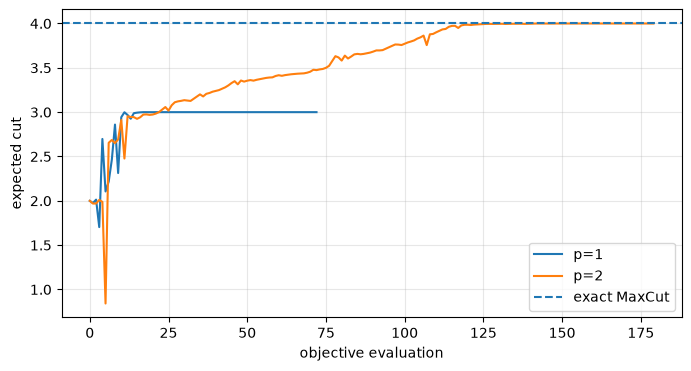

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(opt_p1["history"], label="p=1")
plt.plot(opt_p2["history"], label="p=2")
plt.axhline(4.0, linestyle="--", label="exact MaxCut")
plt.xlabel("objective evaluation")
plt.ylabel("expected cut")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Sampling the optimized circuits

We use Qiskit's `StatevectorSampler` with the same final-shot count (we will simulate 100 shot count).

In [20]:
sampler = StatevectorSampler(seed=42)

def sample_optimized(result_dict, shots=100, seed=None):
    qc = qaoa_circuit(
        result_dict["gammas"],
        result_dict["betas"],
        measure=True,
    )

    local_sampler = StatevectorSampler(seed=seed)
    result = local_sampler.run([qc], shots=shots).result()

    # measure_all() creates a register named "meas"
    counts = result[0].data.meas.get_counts()

    return counts

In [21]:
counts_p1 = sample_optimized(opt_p1, shots=100, seed=101)
counts_p2 = sample_optimized(opt_p2, shots=100, seed=102)

print("p=1 counts:", counts_p1)
print("\np=2 counts:", counts_p2)

p=1 counts: {'1100': 9, '0101': 24, '1010': 25, '1001': 7, '1011': 2, '1110': 3, '0110': 9, '0001': 2, '1000': 2, '0011': 10, '1101': 2, '0111': 1, '0010': 1, '0100': 1, '1111': 2}

p=2 counts: {'0101': 47, '1010': 53}


## Qiskit bit-string order

Qiskit displays measured classical strings in the order

$$
q_{n-1}\cdots q_1q_0.
$$

Our graph vertices are labeled \(0,1,2,3\). For the present symmetric MaxCut graph,
the optimal patterns are still recognizable as `0101` and `1010`.

For a more general graph, always decode Qiskit strings carefully before associating bits with graph vertices.

In [22]:
def most_frequent_bitstring(counts):
    return max(counts, key=counts.get)

print("Most frequent p=1 bit string:",
      most_frequent_bitstring(counts_p1))
print("Most frequent p=2 bit string:",
      most_frequent_bitstring(counts_p2))

Most frequent p=1 bit string: 1010
Most frequent p=2 bit string: 1010


## Plot the sampled distributions

We reproduce the spirit of the PennyLane histogram by displaying all \(16\) computational-basis strings.

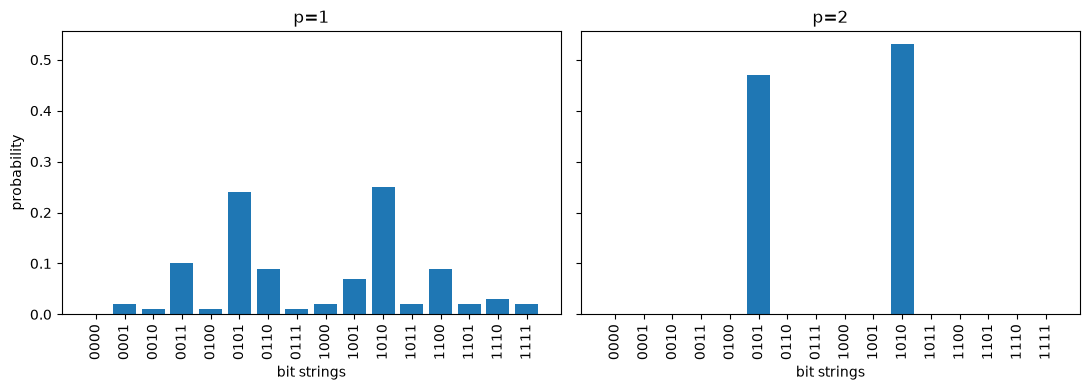

In [24]:
def counts_to_all_probabilities(counts, n_qubits):
    shots = sum(counts.values())
    labels = [format(i, f"0{n_qubits}b") for i in range(2**n_qubits)]
    probs = [counts.get(label, 0) / shots for label in labels]
    return labels, probs

labels1, probs1 = counts_to_all_probabilities(counts_p1, n_qubits)
labels2, probs2 = counts_to_all_probabilities(counts_p2, n_qubits)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].bar(labels1, probs1)
axes[0].set_title("p=1")
axes[0].set_xlabel("bit strings")
axes[0].set_ylabel("probability")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(labels2, probs2)
axes[1].set_title("p=2")
axes[1].set_xlabel("bit strings")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## Success probability

A more robust metric than the single most frequent bit string is

$$
P_{\rm opt}
=
P(0101)+P(1010).
$$

In [25]:
optimal_qiskit_strings = {"0101", "1010"}

def optimal_probability(counts):
    shots = sum(counts.values())
    return sum(
        count for bitstring, count in counts.items()
        if bitstring in optimal_qiskit_strings
    ) / shots

print("P(optimal), p=1 =", optimal_probability(counts_p1))
print("P(optimal), p=2 =", optimal_probability(counts_p2))

P(optimal), p=1 = 0.49
P(optimal), p=2 = 1.0


## Finite-shot objective during optimisation

Above, we used an exact `StatevectorEstimator` objective and finite shots only for the final measurement. This cleanly separates **optimisation error** from **sampling error**.

If one wants a closer reproduction of a shot-based NISQ workflow, estimate the cost directly from computational-basis samples.

For MaxCut, this is  simple because the objective (cost) is diagonal in the computational basis:

$$
\langle C\rangle
=
\sum_z P(z)\,C(z).
$$

In [26]:
def qiskit_string_to_vertex_bits(qiskit_string):
    # qiskit string q3 q2 q1 q0 -> vertex order q0 q1 q2 q3
    return tuple(int(b) for b in qiskit_string[::-1])

def sampled_expected_cut(params, shots=20, seed=123):
    params = np.asarray(params, dtype=float)
    p = len(params) // 2

    qc = qaoa_circuit(
        params[:p],
        params[p:],
        measure=True,
    )

    local_sampler = StatevectorSampler(seed=seed)
    result = local_sampler.run([qc], shots=shots).result()
    counts = result[0].data.meas.get_counts()

    total = sum(counts.values())
    value = 0.0

    for bitstring, count in counts.items():
        vertex_bits = qiskit_string_to_vertex_bits(bitstring)
        value += (count / total) * cut_value(vertex_bits)

    return value

print(
    "20-shot estimate at optimized p=1 parameters:",
    sampled_expected_cut(
        np.concatenate([opt_p1["gammas"], opt_p1["betas"]]),
        shots=20,
        seed=999,
    ),
)

20-shot estimate at optimized p=1 parameters: 3.4000000000000004


Because a 20-shot objective is noisy and non-smooth, gradient-free or stochastic optimizers such as COBYLA or SPSA are generally more natural than deterministic gradient methods.

20-shot estimates: [3.3000000000000003, 3.2, 3.2000000000000006, 3.3000000000000007, 2.9000000000000004, 3.2000000000000006, 3.2000000000000006, 3.2000000000000006, 3.3000000000000003, 3.2000000000000006, 2.7, 2.7, 3.1000000000000005, 3.0, 2.5999999999999996, 3.6000000000000005, 2.5999999999999996, 3.1, 3.1000000000000005, 2.8]
mean = 3.0650000000000004
std  = 0.26129485260907864


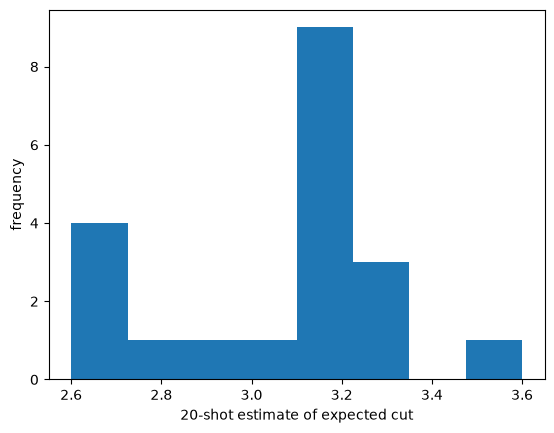

In [27]:
p1_vector = np.concatenate([opt_p1["gammas"], opt_p1["betas"]])

estimates = [
    sampled_expected_cut(
        p1_vector,
        shots=20,
        seed=1000 + k,
    )
    for k in range(20)
]

print("20-shot estimates:", estimates)
print("mean =", np.mean(estimates))
print("std  =", np.std(estimates))

plt.hist(estimates, bins=8)
plt.xlabel("20-shot estimate of expected cut")
plt.ylabel("frequency")
plt.show()

## Modern way & shortcut: Qiskit's built-in `qaoa_ansatz`

The implementation above is useful for understanding.

For production code, Qiskit can construct the QAOA circuit directly from a cost Hamiltonian using `qaoa_ansatz`.

For MaxCut, minimising

$$
H_{\rm Ising}
=
\frac12
\sum_{(j,k)\in E}Z_jZ_k
$$

is equivalent to maximising the cut value up to the constant $|E|/2$.

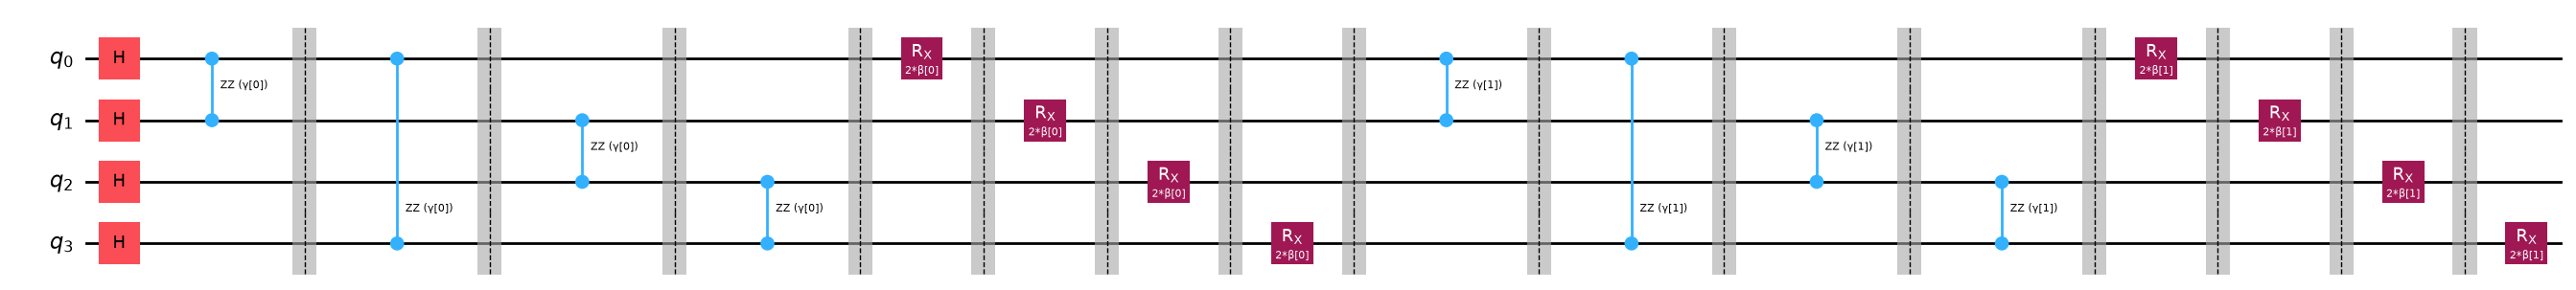

Number of parameters: 4


In [29]:
from qiskit.circuit.library import qaoa_ansatz

ising_cost = SparsePauliOp.from_sparse_list(
    [("ZZ", [j, k], 0.5) for j, k in graph],
    num_qubits=n_qubits,
)

built_in_qaoa = qaoa_ansatz(
    ising_cost,
    reps=2,
    insert_barriers=True,
    flatten=True,
)

display(built_in_qaoa.draw("mpl", fold=-1))
print("Number of parameters:", built_in_qaoa.num_parameters)

## Resource estimation in Qiskit

Core Qiskit's standard transpiler answers a question: **what does the circuit look like after decomposition to a chosen hardware-like basis?**

We can estimate:

- qubits;
- circuit depth;
- circuit size;
- CX count;
- basis-gate counts.

This is very useful for an NISQ-oriented implementations.

In [30]:
def qiskit_resources(gammas, betas, optimization_level=1):
    qc = qaoa_circuit(gammas, betas)

    tqc = transpile(
        qc,
        basis_gates=["rz", "sx", "x", "cx"],
        optimization_level=optimization_level,
    )

    return {
        "qubits": tqc.num_qubits,
        "depth": tqc.depth(),
        "size": tqc.size(),
        "ops": dict(tqc.count_ops()),
        "cx": tqc.count_ops().get("cx", 0),
        "transpiled_circuit": tqc,
    }

res_p1 = qiskit_resources(opt_p1["gammas"], opt_p1["betas"])
res_p2 = qiskit_resources(opt_p2["gammas"], opt_p2["betas"])

print("p=1 resources")
for key, value in res_p1.items():
    if key != "transpiled_circuit":
        print(f"  {key}: {value}")

print("\np=2 resources")
for key, value in res_p2.items():
    if key != "transpiled_circuit":
        print(f"  {key}: {value}")

p=1 resources
  qubits: 4
  depth: 17
  size: 44
  ops: {'rz': 24, 'sx': 12, 'cx': 8}
  cx: 8

p=2 resources
  qubits: 4
  depth: 28
  size: 76
  ops: {'rz': 40, 'sx': 20, 'cx': 16}
  cx: 16


## Logical gate-count check

In [32]:
def logical_resource_formula(n_vertices, n_edges, p):
    return {
        "H": n_vertices,
        "RX": p * n_vertices,
        "RZ": p * n_edges,
        "CNOT": 2 * p * n_edges,
    }

print(logical_resource_formula(
    n_vertices=n_qubits,
    n_edges=len(graph),
    p=2,
))

{'H': 4, 'RX': 8, 'RZ': 8, 'CNOT': 16}


### Suggested exercises

1. Repeat the calculation for \(p=3\).
2. Replace the exact Estimator objective by a 20-shot sampled objective.
3. Compare COBYLA and SPSA.
4. Add a depolarizing-noise model with Qiskit Aer.
5. Change one edge of the graph and verify that the optimal bit strings change.
6. Compare the explicit $U_C,U_B$ implementation against Qiskit's built-in `qaoa_ansatz`.